In [1]:
#Importiamo le librerie necessarie al progetto
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer #Dataset scelto
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split

#Algoritmi di classificazione scelti
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score,recall_score, f1_score
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

#Librerie necessarie al DeepLearning
import tensorflow as tf
from tensorflow import keras
from keras import layers



In [2]:
#Caricamento del dataset
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names

#Stampiamo delle informazioni sui dati
print(X.shape)
print(feature_names,"\n")
print(data.target_names)

(569, 30)
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension'] 

['malignant' 'benign']


In [3]:
#Analisi delle features
#Trasformiamo i dati del dataset in una tabella strutturata (DataFrame)
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y
"""
Describe è utile perché ci permette di capire la distribuzione delle feature,
vedere scale diverse tra variabili e giustificare StandardScaler prima della PCA
"""
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


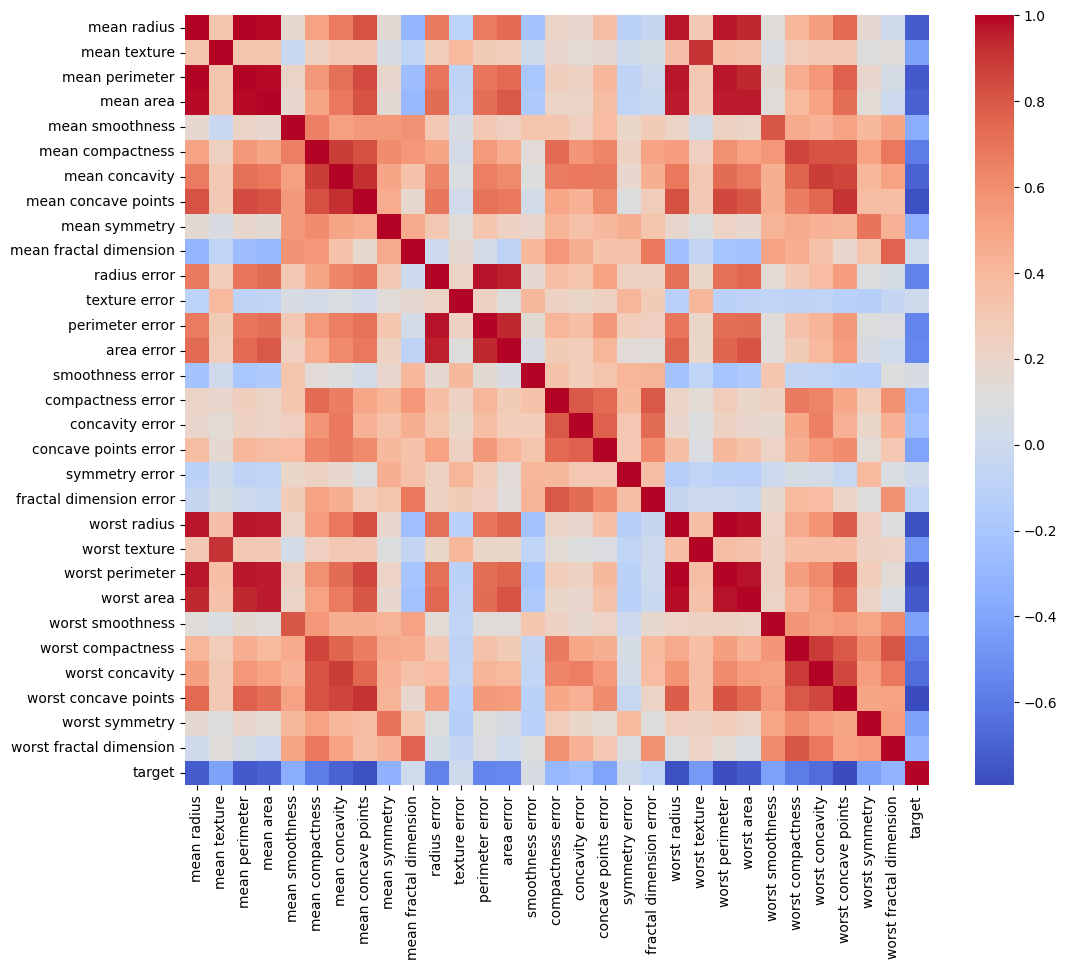

In [4]:
#Mostriamo la matrice di correlazione
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(),cmap="coolwarm")
plt.show()

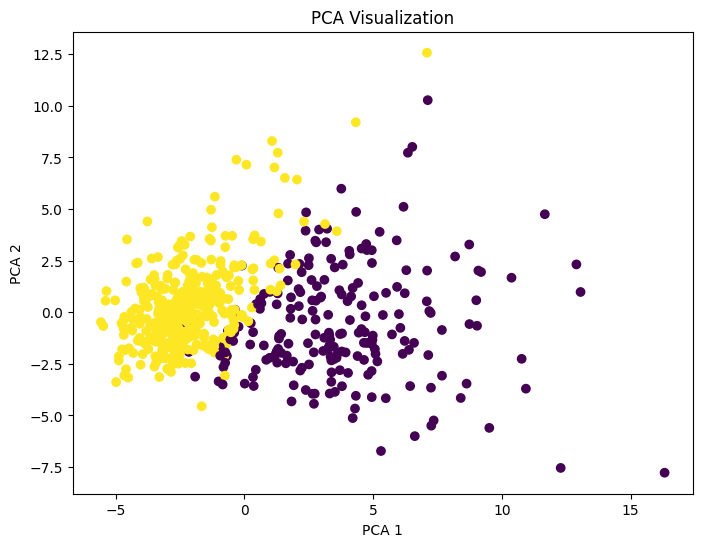

In [19]:
#Standardizzazione dei dati

scaler = StandardScaler()
#Portiamo le feature tutte sulla stessa scala media=0 e deviazione standard=1
#Senza un opportuno scaling la PCA sarebbe dominata dalle feature che hanno valori grandi
X_scaled = scaler.fit_transform(X)
#Troviamo le due direzioni in cui abbiamo massima varianza e riduciamo la dimensionalità
#Viene sfruttata una matrice di covarianza
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='viridis')
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("PCA Visualization")
plt.show()

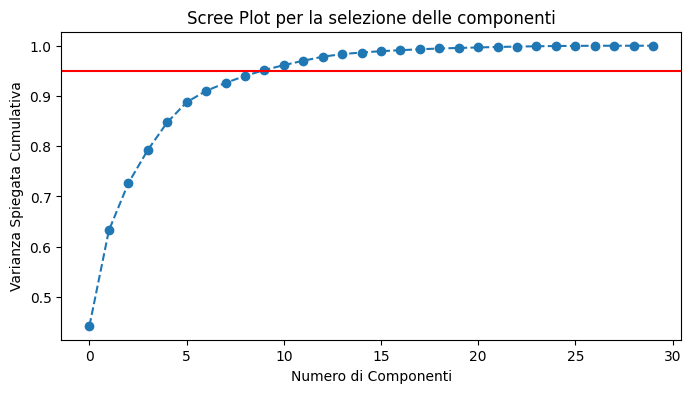

In [6]:
pca_full = PCA().fit(X_scaled)
plt.figure(figsize=(8,4))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_), marker='o', linestyle='--')
plt.xlabel('Numero di Componenti')
plt.ylabel('Varianza Spiegata Cumulativa')
plt.axhline(y=0.95, color='r', linestyle='-')
plt.title('Scree Plot per la selezione delle componenti')
plt.show()

In [7]:
#Dividiamo il dataset in train set e test set
#Il 20 % del dataset sarà usato nel test set
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


Accuracy :  0.9736842105263158
Precision :  0.9722222222222222
Recall :  0.9859154929577465
F1 :  0.9790209790209791


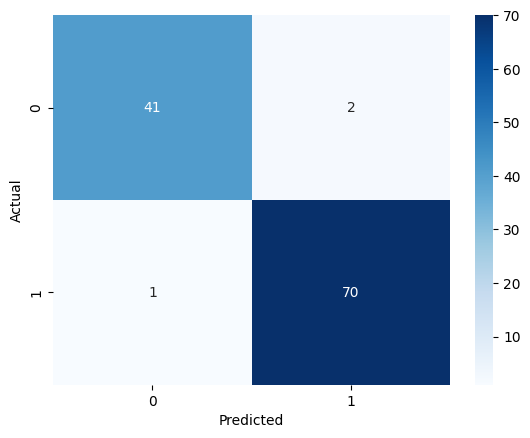

In [8]:
#Model 1 - Logistic Regression
model_lr = LogisticRegression()
model_lr = model_lr.fit(X_train, y_train)


y_pred_lr = model_lr.predict(X_test)
#Indica la percentuale di previsioni corrette sul totale dei casi nel test set
print("Accuracy : ", accuracy_score(y_test,y_pred_lr))
#Per capire il numero di falsi Positivi
print("Precision : ", precision_score(y_test,y_pred_lr))
#Per capire il numero di falsi negativi
print("Recall : ", recall_score(y_test,y_pred_lr))
#Serve per capire se il modello è sbilanciato verso  recall/precision
print("F1 : ", f1_score(y_test, y_pred_lr))
"""
La confusion matrix consente di analizzare nel dettaglio le prestazioni del modello,
evidenziando non solo il numero di predizioni corrette ma anche la tipologia degli errori,
distinguendo tra falsi positivi e falsi negativi.
"""
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


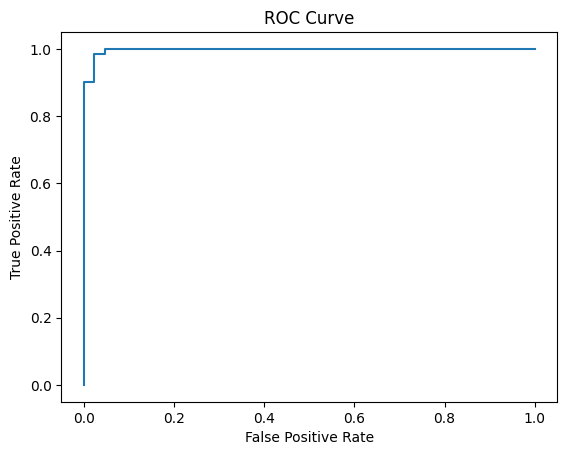

In [9]:
y_prob = model_lr.predict_proba(X_test)[:,1]
fpr,tpr,thresholds = roc_curve(y_test,y_prob)
plt.plot(fpr,tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

[1 0 0 1 1 0 0 0 1 1 1 0 1 0 1 0 1 1 1 0 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 0
 1 0 1 1 0 1 1 1 1 1 1 1 1 0 0 0 1 1 1 1 0 0 1 1 0 0 1 1 1 0 0 1 1 0 0 1 0
 1 1 1 1 1 1 0 1 0 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 1 0 0 1 0 0 1 1 1 0 1 1 0
 1 1 0]
Accuracy :  0.9736842105263158
Precision :  0.9722222222222222
Recall :  0.9859154929577465
F1 :  0.9790209790209791


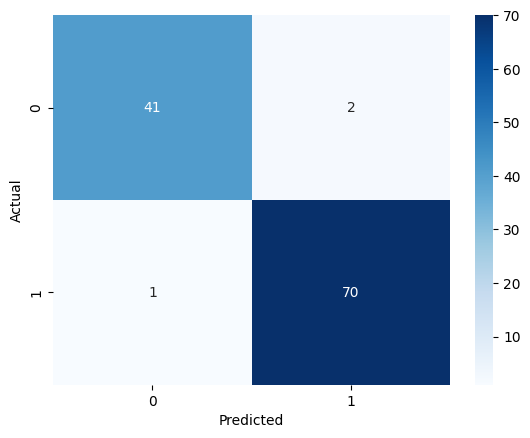

In [10]:
#Model 2 - SVM
model_svm = SVC(probability=True)
model_svm.fit(X_train,y_train)

y_pred_svm = model_svm.predict(X_test)
print(y_pred_svm)
print("Accuracy : ", accuracy_score(y_test,y_pred_svm))
#Per capire il numero di falsi Positivi
print("Precision : ", precision_score(y_test,y_pred_svm))
#Per capire il numero di falsi negativi
print("Recall : ", recall_score(y_test,y_pred_svm))
#Serve per capire se il modello è sbilanciato verso  recall/precision
print("F1 : ", f1_score(y_test, y_pred_svm))

cm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



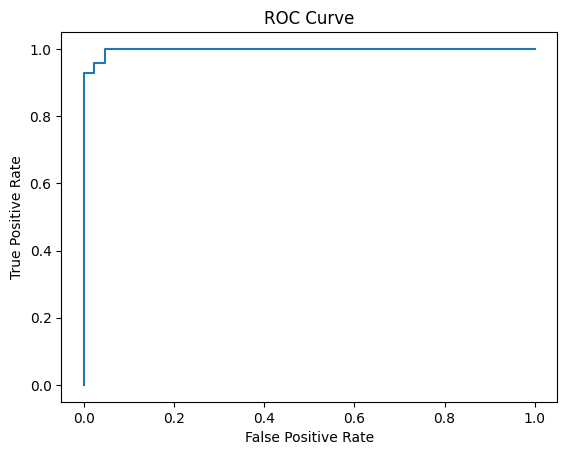

In [11]:
y_prob = model_svm.predict_proba(X_test)[:,1]
fpr,tpr,thresholds = roc_curve(y_test,y_prob)
plt.plot(fpr,tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

Accuracy :  0.9649122807017544
Precision :  0.958904109589041
Recall :  0.9859154929577465
F1 :  0.9722222222222222


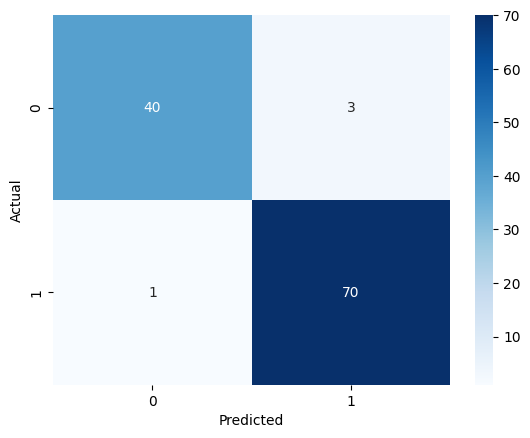

In [12]:
#Model 3 - Random Forest
model_rf = RandomForestClassifier()
model_rf.fit(X_train,y_train)

y_pred_rf = model_rf.predict(X_test)
print("Accuracy : ", accuracy_score(y_test,y_pred_rf))
#Per capire il numero di falsi Positivi
print("Precision : ", precision_score(y_test,y_pred_rf))
#Per capire il numero di falsi negativi
print("Recall : ", recall_score(y_test,y_pred_rf))
#Serve per capire se il modello è sbilanciato verso  recall/precision
print("F1 : ", f1_score(y_test, y_pred_rf))

cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

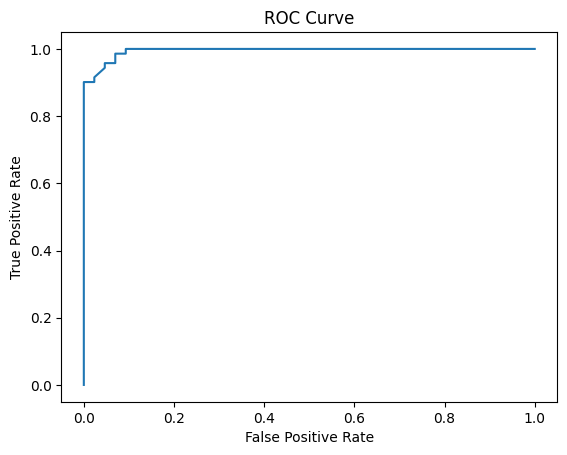

In [13]:
y_prob = model_rf.predict_proba(X_test)[:,1]
fpr,tpr,thresholds = roc_curve(y_test,y_prob)
plt.plot(fpr,tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [14]:
#Deep Learning
#Rete neurale sequenziale, relu per introdurre non linearità, sigmoide nell'ultimo strato perché restituisce probabilità
model_dl =  keras.Sequential([
    layers.Dense(32, activation='relu',input_shape=(30,)), #30 perché abbiamo 30 features
    layers.Dense(16, activation='relu'), layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model_dl.compile(optimizer="adam", #Algoritmo di aggiornamento dei pesi, calcola l'errore e modifica i pesi
                 loss='binary_crossentropy', #La funzione di errore, misura quanto sbaglia la rete (binary perché il problema è binario)
                 metrics=['accuracy']) #La metrica che vogliamo monitorare durante il training

In [16]:
history = model_dl.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

test_loss, test_acc = model_dl.evaluate(X_test, y_test)
print("Test accuracy :",test_acc)
y_pred_dl = (model_dl.predict(X_test) > 0.5).astype(int)


Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.6374 - loss: 0.5787 - val_accuracy: 0.6703 - val_loss: 0.5193
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7363 - loss: 0.4638 - val_accuracy: 0.7912 - val_loss: 0.4116
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8599 - loss: 0.3872 - val_accuracy: 0.8681 - val_loss: 0.3423
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9066 - loss: 0.3277 - val_accuracy: 0.9121 - val_loss: 0.2889
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9313 - loss: 0.2759 - val_accuracy: 0.9451 - val_loss: 0.2479
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9341 - loss: 0.2354 - val_accuracy: 0.9560 - val_loss: 0.2157
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9396 - loss: 0.2018 - val_accuracy: 0.9560 - val_loss: 0.1910
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9478 - loss: 0.1745 - val_accuracy: 0.9670 - val_loss

Precision :  0.9594594594594594
Recall :  1.0
F1 :  0.9793103448275862


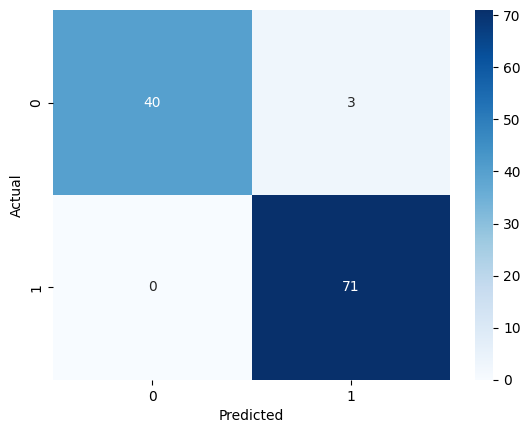

In [17]:
#Per capire il numero di falsi Positivi
print("Precision : ", precision_score(y_test,y_pred_dl))
#Per capire il numero di falsi negativi
print("Recall : ", recall_score(y_test,y_pred_dl))
#Serve per capire se il modello è sbilanciato verso  recall/precision
print("F1 : ", f1_score(y_test, y_pred_dl))


cm = confusion_matrix(y_test, y_pred_dl)
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


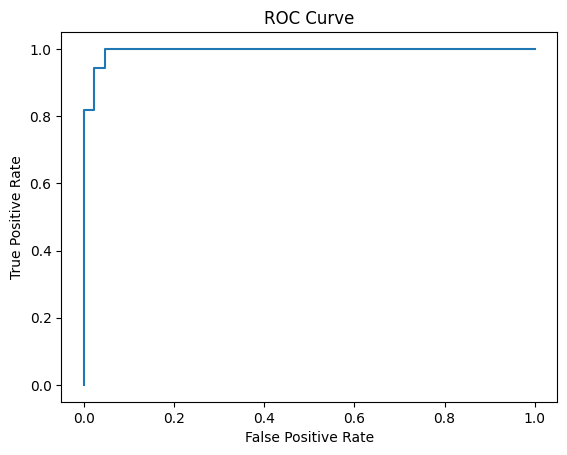

In [18]:
y_pred_dl = model_dl.predict(X_test)
fpr,tpr,thresholds = roc_curve(y_test,y_pred_dl)
plt.plot(fpr,tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()